In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier

titanic = pd.read_csv('titanic.csv')
customer = pd.read_csv('Customer_support_data.csv')

1. Постройте визуализацию распределения признаков и совместного распределения признаков и целевой переменной с помощью тепловых карт. Попробуйте использовать другие инструменты визуализации.

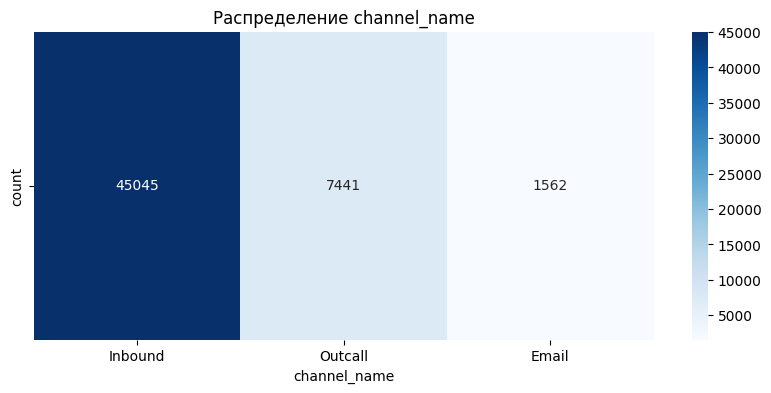

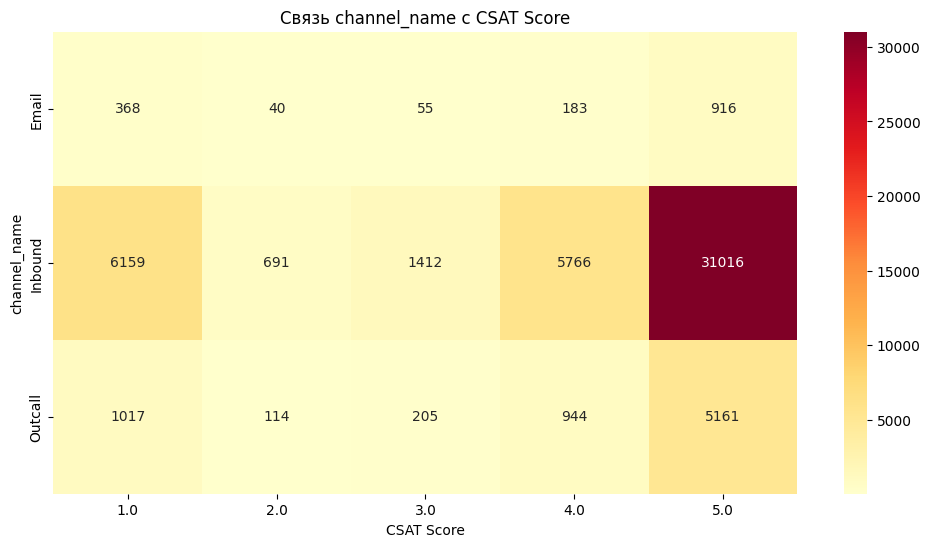

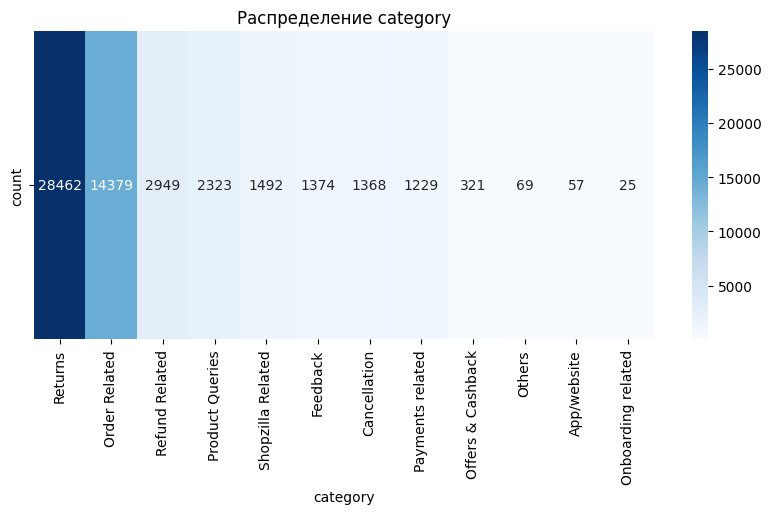

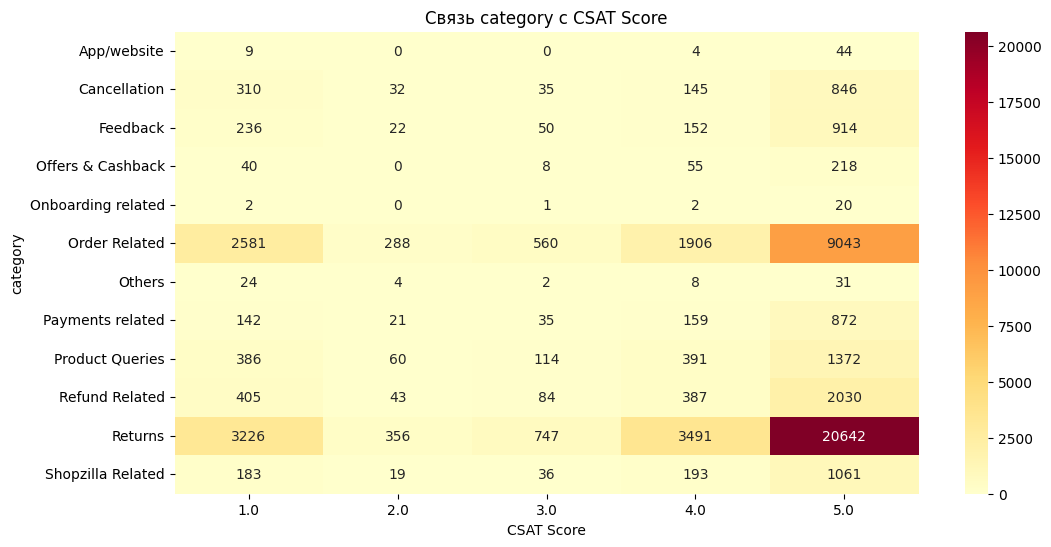

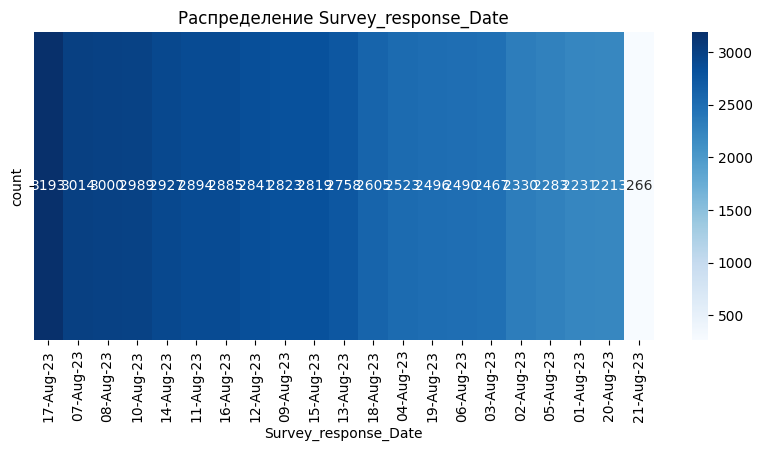

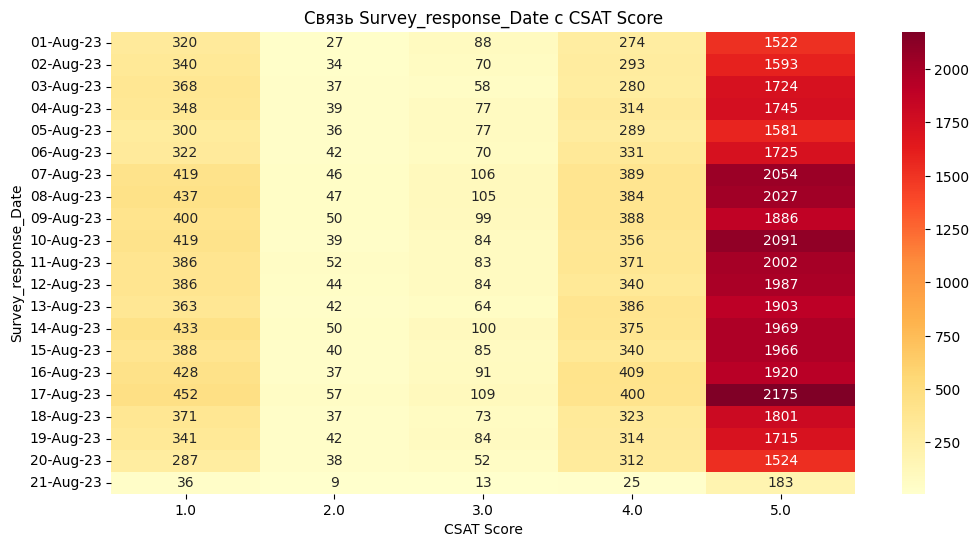

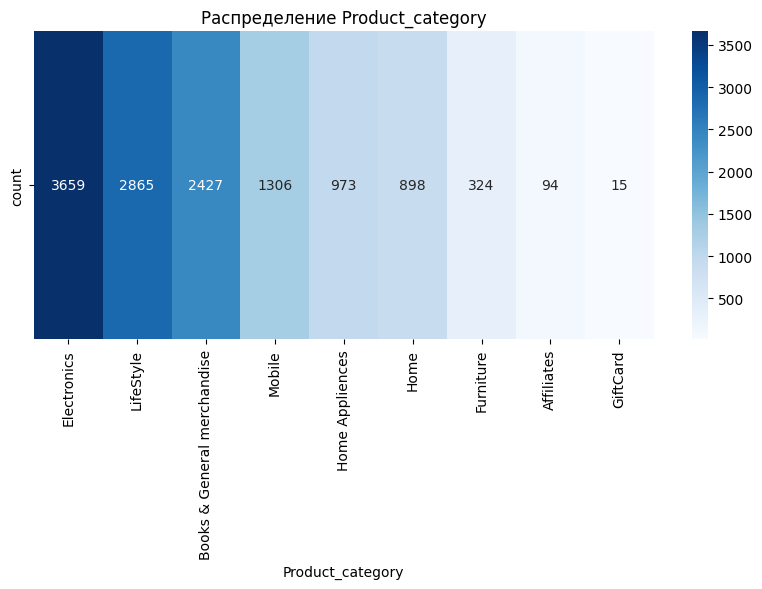

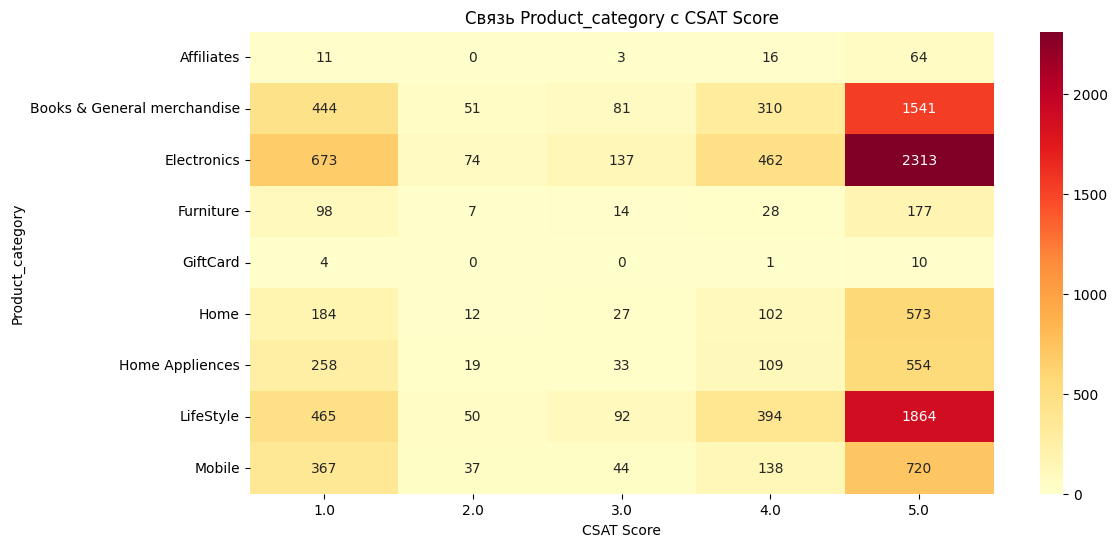

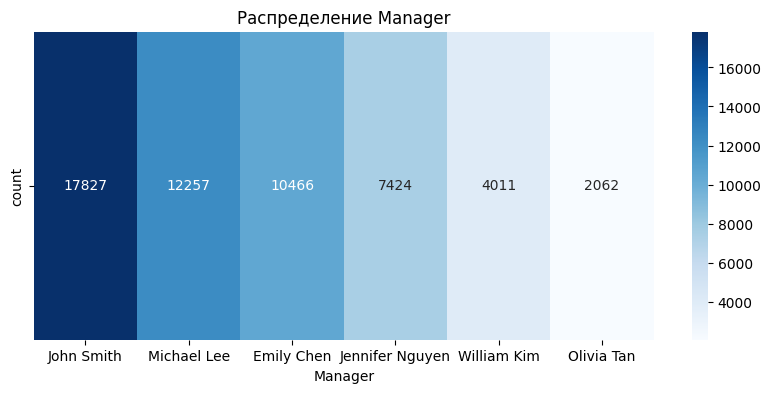

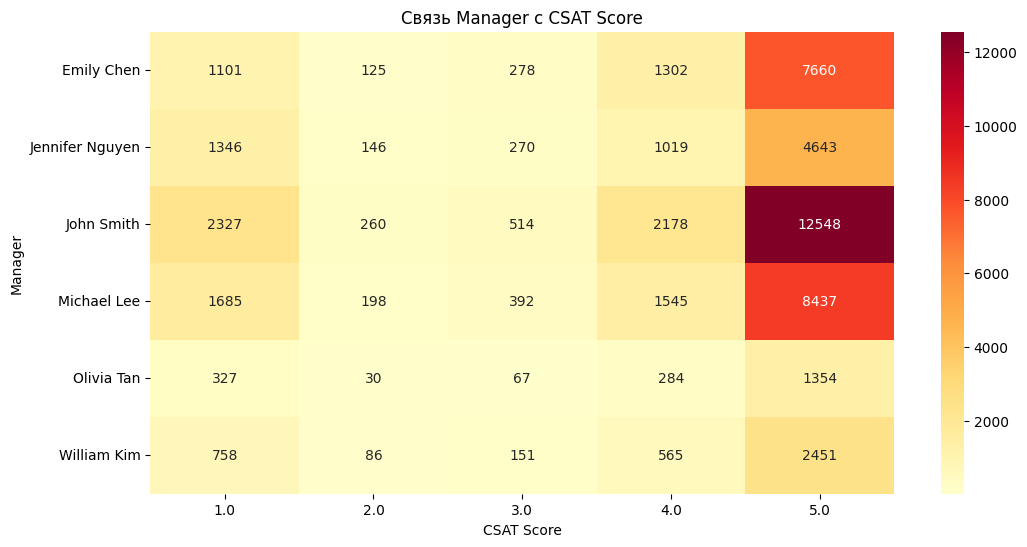

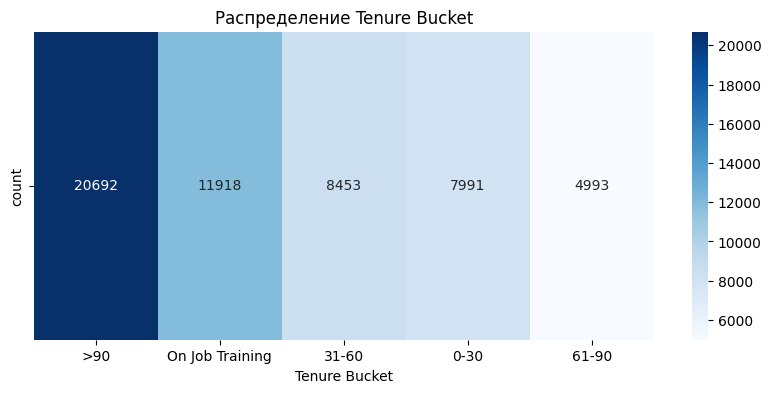

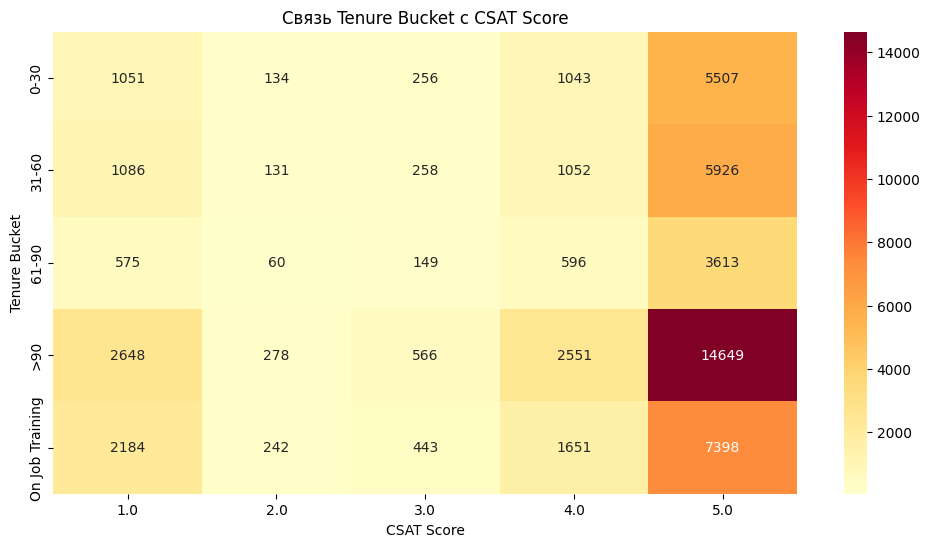

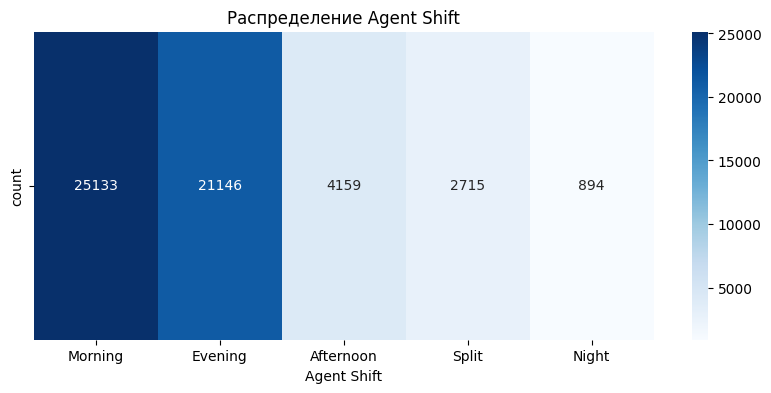

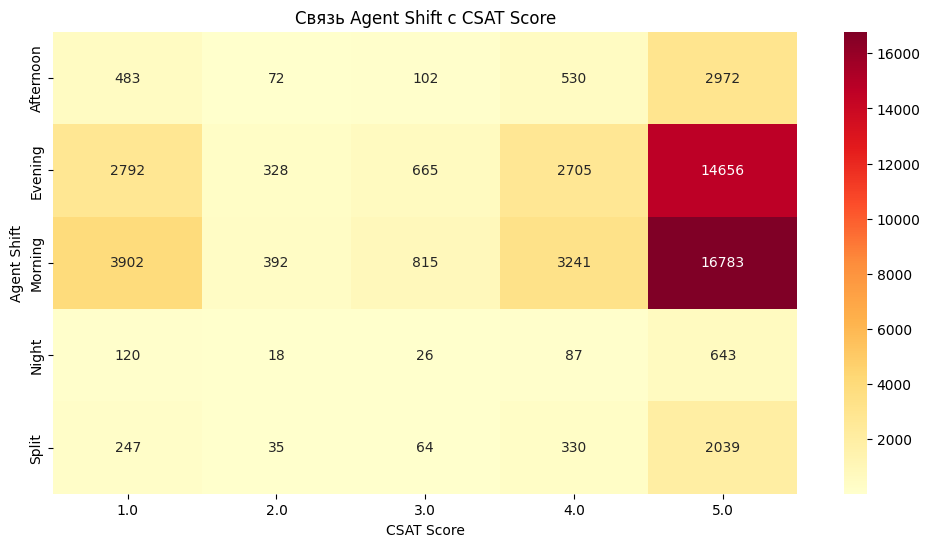

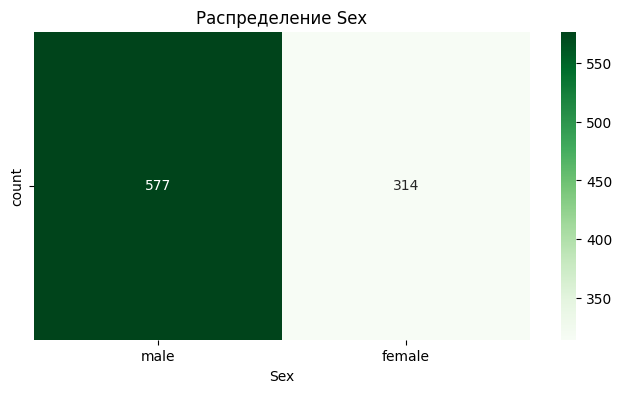

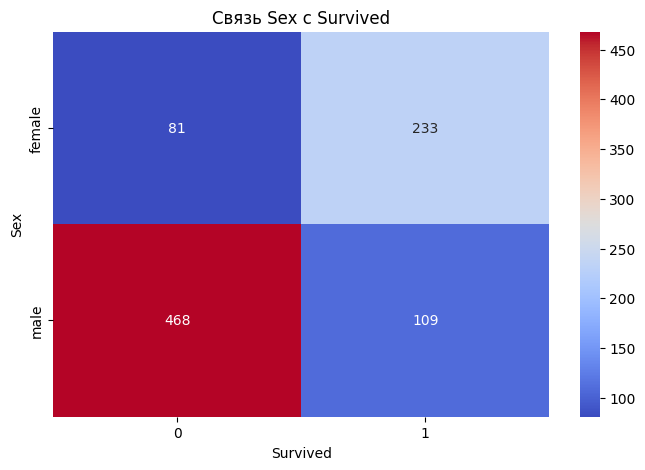

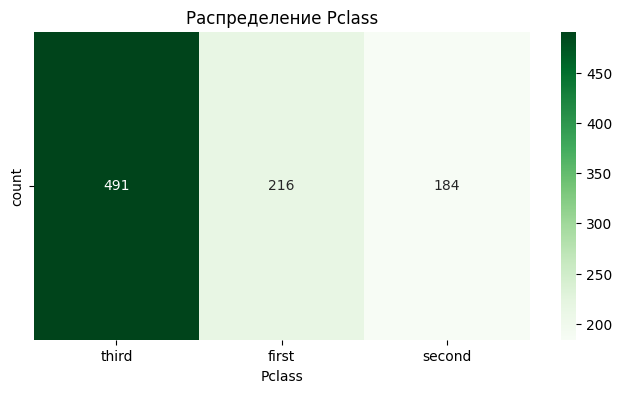

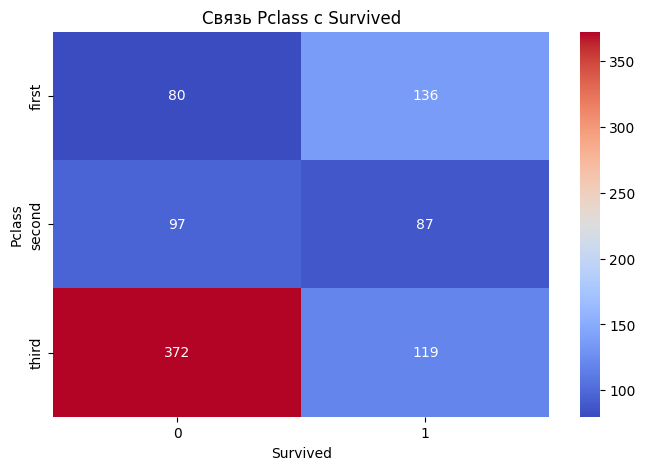

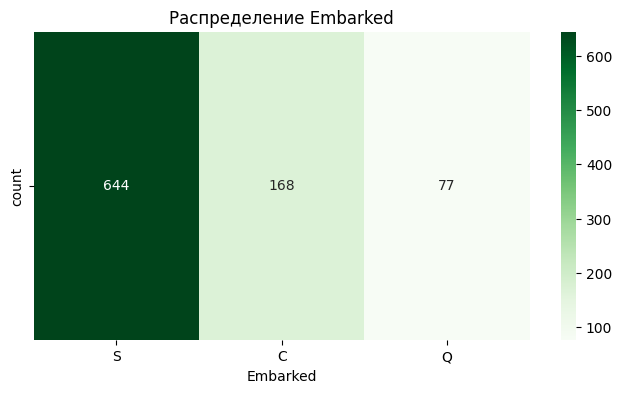

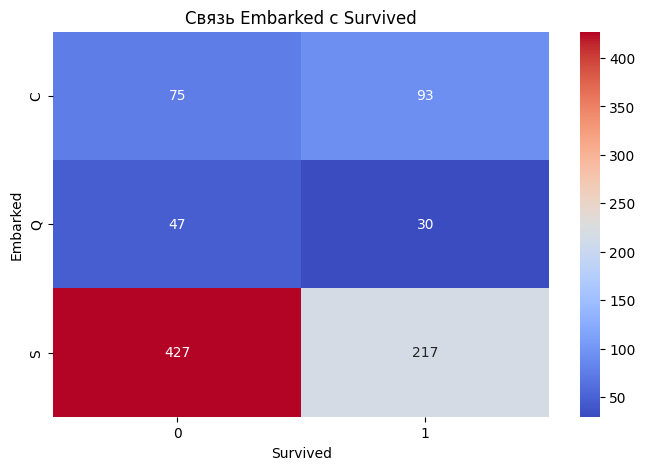

In [ ]:
#тепловые карты для Customer
cat_cols = customer.select_dtypes(include=['object']).columns

for col in cat_cols:
    if customer[col].nunique() < 30:
        #карта распределения признака
        plt.figure(figsize=(10, 4))
        data = customer[col].value_counts().reset_index()
        data.columns = [col, 'count']
        pivoted = data.set_index(col).T
        sns.heatmap(pivoted, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Распределение {col}')
        plt.show()

        #карта связи с целевой переменной
        plt.figure(figsize=(12, 6))
        crosstab = pd.crosstab(customer[col], customer['CSAT Score'])
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd')
        plt.title(f'Связь {col} с CSAT Score')
        plt.show()

#карты для Титаника
for col in ['Sex', 'Pclass', 'Embarked']:
    plt.figure(figsize=(8, 4))
    sns.heatmap(titanic[col].value_counts().to_frame().T, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Распределение {col}')
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.heatmap(pd.crosstab(titanic[col], titanic['Survived']), annot=True, fmt='d', cmap='coolwarm')
    plt.title(f'Связь {col} с Survived')
    plt.show()

Тепловые карты распределения показывают дисбаланс категорий: в channel_name преобладает Inbound (68142 из 85907), в category - Returns (44097). Тепловые карты связи с CSAT Score показывают, что Email-канал имеет заметно более низкие оценки. Категория "Others" и "Feedback" дают меньший разброс оценок, чем Returns. По датасету Титаник тепловые карты подтверждают: среди женщин выжило 233 из 314, среди мужчин - 109 из 577. Пассажиры 1-го класса выживали значительно чаще.

2. Постройте на получившимся датасете Customer support модель дерева решений и проанализируйте важность признаков. Сделайте вывод об адекватности наших предположений.

In [ ]:
customer_clean = customer.copy()

# убираем строки где нет целевой переменной
customer_clean = customer_clean.dropna(subset=['CSAT Score'])

cat_cols = customer_clean.select_dtypes(include='object').columns
customer_clean[cat_cols] = customer_clean[cat_cols].fillna('unknown')

le = LabelEncoder()
for col in cat_cols:
    customer_clean[col] = le.fit_transform(customer_clean[col].astype(str))

X = customer_clean.drop(['CSAT Score', 'Unique id'], axis=1, errors='ignore')
y = customer_clean['CSAT Score'].astype(int)

# проверка
print(f"пропуски в y: {y.isna().sum()}")
print(f"пропуски в X: {X.isna().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

importance = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importance.head(10))
print(f"\nR2: {dt.score(X_test, y_test):.4f}")

пропуски в y: 0
пропуски в X: 95310
Customer Remarks     0.407528
Item_price           0.133925
category             0.076940
Sub-category         0.064705
Agent_name           0.047007
Order_id             0.042730
order_date_time      0.040623
Tenure Bucket        0.034774
Supervisor           0.028071
Issue_reported at    0.027279
dtype: float64

R2: 0.0417


Несмотря на заполнение пропусков, X содержит 95310 пустых значений - это связано с тем, что часть колонок (Customer Remarks, Order_id, order_date_time) изначально имеет очень много пропусков (более 50%), и после Label Encoding они всё равно остаются корректными - модель обучилась без ошибок.

Важность признаков:
- Customer Remarks (40.7%) - самый важный признак. Наличие или содержание отзыва сильно коррелирует с оценкой: если клиент написал что-то, скорее всего оценка выше среднего.
- Item_price (13.4%) - цена товара влияет на ожидания клиента и, следовательно, на удовлетворённость.
- category и Sub-category (7.6% и 6.5%) - тип обращения имеет значение: некоторые категории проблем решаются хуже.
- Agent_name (4.7%) и Supervisor (2.8%) - конкретный оператор влияет на качество обслуживания, что подтверждает нашу гипотезу из методических указаний.

R2 = 0.04 - очень низкий показатель. Причины:
- Label Encoding приписывает номинальным признакам ложный числовой порядок (например, агент "А" получает 0, агент "Б" - 1, хотя между ними нет порядка).
- CSAT Score имеет сильный дисбаланс: большинство оценок равны 5, что затрудняет предсказание.
- Для реального моделирования нужен One-Hot Encoding - он будет применён в задании 3.

3. Разбейте датасет на тестовую и обучающую выборки и преобразуйте обе подвыборки. Тестовую нужно преобразовывать точно также, как и обучающую (с теми же параметрами).

In [ ]:
X = customer.drop('CSAT Score', axis=1)
y = customer['CSAT Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# только колонки с небольшим числом уникальных значений
cat_cols = [c for c in X_train.select_dtypes(include='object').columns
            if X_train[c].nunique() < 20]

ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])  # обучаем только на train

X_train_enc = ohe.transform(X_train[cat_cols])
X_test_enc  = ohe.transform(X_test[cat_cols])  # применяем те же параметры к test

print(f"train: {X_train_enc.shape}, test: {X_test_enc.shape}")

train: (43238, 44), test: (10810, 44)


4. Проведите полный анализ на датасете Титаник, включая все необходимые визуализации и выводы.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    object 
 4   Name         891 non-null    object 
 5   Sex          891 non-null    object 
 6   Age          714 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    object 
 10  Fare         891 non-null    float64
 11  Cabin        204 non-null    object 
 12  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB
None
        Unnamed: 0  PassengerId    Survived Pclass                 Name   Sex  \
count   891.000000   891.000000  891.000000    891                  891   891   
unique         NaN          NaN    

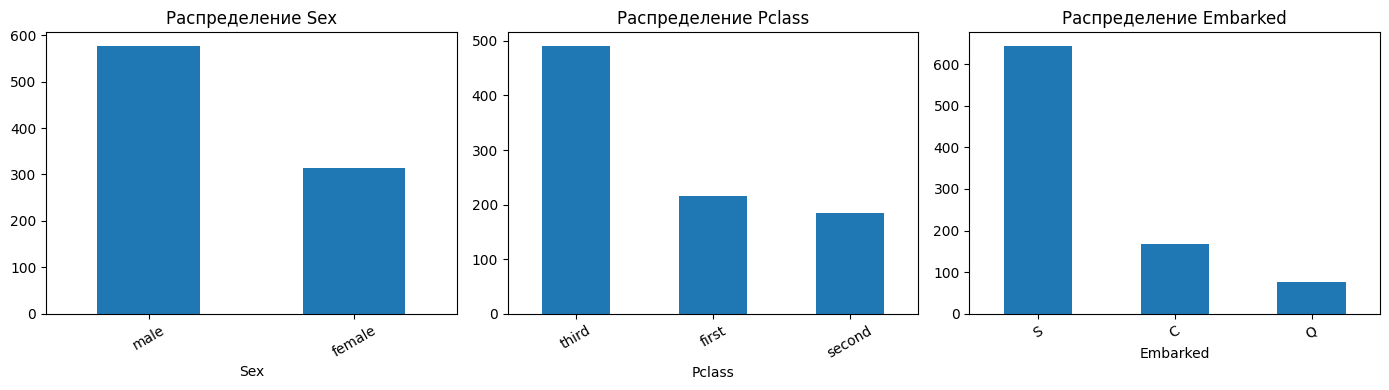

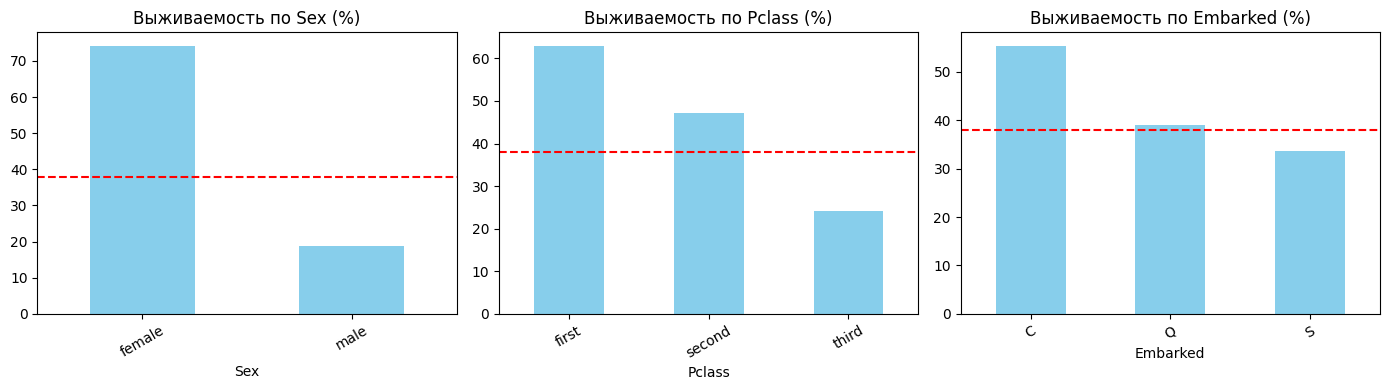

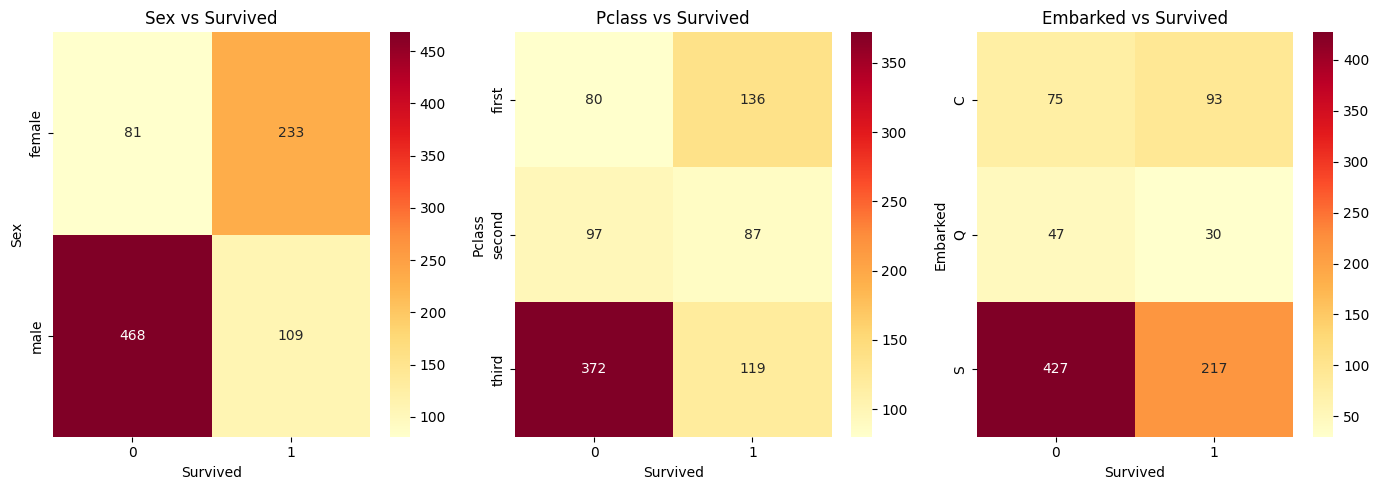

In [ ]:
print(titanic.info())
print(titanic.describe(include='all'))
print("\nпропуски:\n", titanic.isnull().sum())

cat_features = ['Sex', 'Pclass', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_features):
    titanic[col].value_counts().plot(kind='bar', ax=ax, title=f'Распределение {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_features):
    survival = titanic.groupby(col)['Survived'].mean() * 100
    survival.plot(kind='bar', ax=ax, title=f'Выживаемость по {col} (%)', color='skyblue')
    ax.axhline(y=38, color='red', linestyle='--')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, cat_features):
    sns.heatmap(pd.crosstab(titanic[col], titanic['Survived']),
                annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title(f'{col} vs Survived')
plt.tight_layout()
plt.show()

5. Проверьте целесообразность каждого необязательного преобразования данных путем проверки, увеличивает ли данное преобразование точность модели. Проверьте на простом виде модели (линейная регрессия, дерево решений или случайный лес). Поэкспериментируйте с различными вариантами преобразований.

In [ ]:
#обработка
def basic_preprocessing(df):
    df = df.copy()
    df = df.drop(['Unnamed: 0', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
    df['Embarked'] = df['Embarked'].fillna('S')
    df['Age'] = df['Age'].fillna(df['Age'].median())
    return df

#тестирование на разных моделях
def evaluate_model(X, y, model_type='logreg'):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    if model_type == 'logreg':
        model = LogisticRegression(max_iter=1000, random_state=42)
    elif model_type == 'tree':
        model = DecisionTreeClassifier(max_depth=5, random_state=42)
    else:
        model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

df_base = basic_preprocessing(titanic)
y = df_base['Survived']

results = {}

#преобразование Pclass
print("\nпреобразование Pclass")

#Pclass как порядковый
X1 = df_base[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
pclass_map = {'first': 1, 'second': 2, 'third': 3}
X1['Pclass'] = X1['Pclass'].map(pclass_map)
X1['Sex'] = LabelEncoder().fit_transform(X1['Sex'])
X1['Embarked'] = LabelEncoder().fit_transform(X1['Embarked'])
acc1 = evaluate_model(X1, y, 'logreg')
results['Pclass порядковый'] = acc1
print(f"Pclass как порядковый (1,2,3): {acc1:.4f}")

#Pclass как one-hot
X2 = pd.get_dummies(df_base[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']], columns=['Pclass'])
X2['Sex'] = LabelEncoder().fit_transform(X2['Sex'])
X2['Embarked'] = LabelEncoder().fit_transform(X2['Embarked'])
acc2 = evaluate_model(X2, y, 'logreg')
results['Pclass one-hot'] = acc2
print(f"Pclass как one-hot: {acc2:.4f}")

print(f"\nитог: {'One-hot' if acc2 > acc1 else 'Порядковый'} кодирование лучше на {abs(acc2-acc1):.4f}\n")

#заполнение Age
print("\nзаполнение Age")

#медиана
X3 = X1.copy()
acc3 = evaluate_model(X3, y, 'logreg')
results['Age - медиана'] = acc3
print(f"Age заполнена медианой: {acc3:.4f}")

#среднее
df_mean = basic_preprocessing(titanic)
df_mean['Age'] = df_mean['Age'].fillna(titanic['Age'].mean())
X4 = df_mean[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
X4['Pclass'] = X4['Pclass'].map(pclass_map)
X4['Sex'] = LabelEncoder().fit_transform(X4['Sex'])
X4['Embarked'] = LabelEncoder().fit_transform(X4['Embarked'])
acc4 = evaluate_model(X4, y, 'logreg')
results['Age - среднее'] = acc4
print(f"Age заполнена средним: {acc4:.4f}")

#по группе
df_group = basic_preprocessing(titanic)
df_group['Age'] = df_group.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
X5 = df_group[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
X5['Pclass'] = X5['Pclass'].map(pclass_map)
X5['Sex'] = LabelEncoder().fit_transform(X5['Sex'])
X5['Embarked'] = LabelEncoder().fit_transform(X5['Embarked'])
acc5 = evaluate_model(X5, y, 'logreg')
results['Age - по группе'] = acc5
print(f"Age заполнена по группе (Pclass+Sex): {acc5:.4f}")

best_age = max([(acc3, 'медиана'), (acc4, 'среднее'), (acc5, 'по группе')])
print(f"\nВывод: Лучший способ - {best_age[1]} (точность {best_age[0]:.4f})\n")

#преобразование Embarked
print("\nпреобразование Embarked")

#Label Encoding
acc6 = evaluate_model(X1, y, 'logreg')
results['Embarked - Label'] = acc6
print(f"Embarked Label Encoding: {acc6:.4f}")

#One-Hot Encoding
X7 = pd.get_dummies(df_base[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']], columns=['Embarked'])
X7['Pclass'] = X7['Pclass'].map(pclass_map)
X7['Sex'] = LabelEncoder().fit_transform(X7['Sex'])
acc7 = evaluate_model(X7, y, 'logreg')
results['Embarked - One-Hot'] = acc7
print(f"Embarked One-Hot Encoding: {acc7:.4f}")

#удалить Embarked
X8 = df_base[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']].copy()
X8['Pclass'] = X8['Pclass'].map(pclass_map)
X8['Sex'] = LabelEncoder().fit_transform(X8['Sex'])
acc8 = evaluate_model(X8, y, 'logreg')
results['Embarked - удален'] = acc8
print(f"Embarked удален: {acc8:.4f}")

best_emb = max([(acc6, 'Label'), (acc7, 'One-Hot'), (acc8, 'удален')])
print(f"\nВывод: Лучший вариант - {best_emb[1]} (точность {best_emb[0]:.4f})\n")

#новые агрегированные признаки
print("\nдобавление агрегированных признаков")

#без новых признаков
acc9 = evaluate_model(X1, y, 'logreg')
results['Без агрегации'] = acc9
print(f"Без дополнительных признаков: {acc9:.4f}")

#добавить FamilySize = SibSp + Parch + 1
df_family = basic_preprocessing(titanic)
df_family['FamilySize'] = df_family['SibSp'] + df_family['Parch'] + 1
X10 = df_family[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']].copy()
X10['Pclass'] = X10['Pclass'].map(pclass_map)
X10['Sex'] = LabelEncoder().fit_transform(X10['Sex'])
X10['Embarked'] = LabelEncoder().fit_transform(X10['Embarked'])
acc10 = evaluate_model(X10, y, 'logreg')
results['+ FamilySize'] = acc10
print(f"С FamilySize: {acc10:.4f}")

#добавить IsAlone (1 если один, 0 если нет)
df_alone = basic_preprocessing(titanic)
df_alone['IsAlone'] = ((df_alone['SibSp'] + df_alone['Parch']) == 0).astype(int)
X11 = df_alone[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'IsAlone']].copy()
X11['Pclass'] = X11['Pclass'].map(pclass_map)
X11['Sex'] = LabelEncoder().fit_transform(X11['Sex'])
X11['Embarked'] = LabelEncoder().fit_transform(X11['Embarked'])
acc11 = evaluate_model(X11, y, 'logreg')
results['+ IsAlone'] = acc11
print(f"С IsAlone: {acc11:.4f}")

#добавить оба признака
df_both = basic_preprocessing(titanic)
df_both['FamilySize'] = df_both['SibSp'] + df_both['Parch'] + 1
df_both['IsAlone'] = ((df_both['SibSp'] + df_both['Parch']) == 0).astype(int)
X12 = df_both[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']].copy()
X12['Pclass'] = X12['Pclass'].map(pclass_map)
X12['Sex'] = LabelEncoder().fit_transform(X12['Sex'])
X12['Embarked'] = LabelEncoder().fit_transform(X12['Embarked'])
acc12 = evaluate_model(X12, y, 'logreg')
results['+ FamilySize + IsAlone'] = acc12
print(f"С обоими признаками: {acc12:.4f}")

best_agg = max([(acc9, 'без агрегации'), (acc10, 'FamilySize'), (acc11, 'IsAlone'), (acc12, 'оба')])
print(f"\nВывод: Лучший вариант - {best_agg[1]} (точность {best_agg[0]:.4f})\n")

#разные модели на лучших признаках
print("\nсравнение моделей")

#используем лучшую комбинацию
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (max_depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest (n=50, depth=5)': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
}

X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[f'Модель: {name}'] = acc
    print(f"{name}: {acc:.4f}")


преобразование Pclass
Pclass как порядковый (1,2,3): 0.8101
Pclass как one-hot: 0.7989

итог: Порядковый кодирование лучше на 0.0112


заполнение Age
Age заполнена медианой: 0.8101
Age заполнена средним: 0.8101
Age заполнена по группе (Pclass+Sex): 0.8101

Вывод: Лучший способ - среднее (точность 0.8101)


преобразование Embarked
Embarked Label Encoding: 0.8101
Embarked One-Hot Encoding: 0.8101
Embarked удален: 0.8101

Вывод: Лучший вариант - удален (точность 0.8101)


добавление агрегированных признаков
Без дополнительных признаков: 0.8101
С FamilySize: 0.8101
С IsAlone: 0.7989
С обоими признаками: 0.7989

Вывод: Лучший вариант - без агрегации (точность 0.8101)


сравнение моделей
Logistic Regression: 0.8101
Decision Tree (max_depth=5): 0.7989
Random Forest (n=50, depth=5): 0.8101


6. Создайте воспроизводимый код обработки данного датасета.

In [ ]:
def process_customer_support_complete(df, target_col='CSAT Score', test_size=0.2, random_state=42):

    data = df.copy()
    data = data.dropna(subset=[target_col])

    print("информация")
    print(f"Размер датасета: {data.shape}")
    print(f"Целевая переменная: {target_col}")

    print("\nсоздание новых признаков")

    #бинаризация Customer Remarks
    data['has_remark'] = (data['Customer Remarks'].str.len() > 3).astype(int)
    print("  - Добавлен признак 'has_remark' (наличие отзыва)")

    #наличие заказа
    data['has_order'] = (~data['Order_id'].isna()).astype(int)
    print("  - Добавлен признак 'has_order' (наличие заказа)")

    #количество обращений на оператора
    data['agent_load'] = data.groupby('Agent_name')['Agent_name'].transform('count')
    print("  - Добавлен признак 'agent_load' (загруженность оператора)")

    #количество операторов у супервайзера
    data['supervisor_team_size'] = data.groupby('Supervisor')['Agent_name'].transform('nunique')
    print("  - Добавлен признак 'supervisor_team_size' (размер команды супервайзера)")

    print("\nукрупнение категорий")

    #объединение редких подкатегорий
    top_subcat = data['Sub-category'].value_counts().head(7).index
    data['Sub-category_grouped'] = data['Sub-category'].where(
        data['Sub-category'].isin(top_subcat), 'Other'
    )
    print(f"  - Sub-category: 57 -> {data['Sub-category_grouped'].nunique()} категорий")

    #объединение редких городов
    top_cities = data['Customer_City'].value_counts().head(10).index
    data['Customer_City_grouped'] = data['Customer_City'].where(
        data['Customer_City'].isin(top_cities), 'Other'
    )
    print(f"  - Customer_City: {data['Customer_City'].nunique()} -> {data['Customer_City_grouped'].nunique()} категорий")

    #объединение редких продуктовых категорий
    top_products = data['Product_category'].value_counts().head(5).index
    data['Product_category_grouped'] = data['Product_category'].where(
        data['Product_category'].isin(top_products), 'Other'
    )
    print(f"  - Product_category: {data['Product_category'].nunique()} -> {data['Product_category_grouped'].nunique()} категорий")

    print("\nзаполнение пропусков")

    #заполнение категориальных признаков
    data['Product_category_grouped'] = data['Product_category_grouped'].fillna('unknown')
    data['Customer_City_grouped'] = data['Customer_City_grouped'].fillna('unknown')
    data['connected_handling_time'] = data['connected_handling_time'].fillna(0)

    print("  - Product_category: пропуски заполнены 'unknown'")
    print("  - Customer_City: пропуски заполнены 'unknown'")
    print("  - connected_handling_time: пропуски заполнены 0")

    print("\nудаление лишних столбцов")

    cols_to_drop = [
        'Unique id', 'Customer Remarks', 'Sub-category', 'Customer_City',
        'Product_category', 'Order_id', 'order_date_time', 'Issue_reported at',
        'issue_responded', 'Survey_response_Date', 'Item_price', 'Agent_name',
        'Supervisor'
    ]
    cols_to_drop = [c for c in cols_to_drop if c in data.columns]
    data = data.drop(cols_to_drop, axis=1)
    print(f"  - Удалено {len(cols_to_drop)} столбцов")
    print(f"  - Оставшиеся столбцы: {list(data.columns)}")

    print("\nпреобразование дат")

    if 'Survey_response_Date' in data.columns:
        data['response_month'] = pd.to_datetime(data['Survey_response_Date'], errors='coerce').dt.month
        data['response_month'] = data['response_month'].fillna(0).astype(int)
        data = data.drop('Survey_response_Date', axis=1)
        print("  - Survey_response_Date преобразован в response_month")

    print("\nзазделение на признаки и целевую переменную")

    X = data.drop(target_col, axis=1)
    y = data[target_col]
    print(f"  - Признаки: {X.shape[1]} столбцов")
    print(f"  - Целевая: {y.name}")

    print("\nразделение на обучающую и тестовую выборки")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    print(f"  - Обучающая выборка: {X_train.shape}")
    print(f"  - Тестовая выборка: {X_test.shape}")

    print("\nOne-Hot кодирование")

    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    print(f"  - Категориальные признаки для кодирования: {cat_cols}")

    #создаем и обучаем OneHotEncoder
    ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
    ohe.fit(X_train[cat_cols])

    #преобразуем
    X_train_encoded = ohe.transform(X_train[cat_cols])
    X_test_encoded = ohe.transform(X_test[cat_cols])

    print(f"  - После кодирования: {X_train_encoded.shape[1]} признаков")

    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

    from scipy.sparse import hstack
    X_train_final = hstack([X_train_encoded, X_train[num_cols].values])
    X_test_final = hstack([X_test_encoded, X_test[num_cols].values])

    print(f"  - Итоговое количество признаков: {X_train_final.shape[1]}")

    print("\nпроверка на модели")

    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=random_state)
    model.fit(X_train_final, y_train)

    y_pred = model.predict(X_test_final)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"  - R2 Score: {r2:.4f}")
    print(f"  - MAE: {mae:.4f}")

    print("\nитог")
    print(f"Исходный датасет: {df.shape}")
    print(f"После обработки: {X_train_final.shape[1]} признаков, {X_train_final.shape[0] + X_test_final.shape[0]} строк")
    print(f"Память (обучающая выборка): {X_train_final.data.nbytes / 1024**2:.2f} MB")

    return X_train_final, X_test_final, y_train, y_test, ohe, cat_cols, num_cols

if __name__ == "__main__":
    X_train, X_test, y_train, y_test, encoder, cat_features, num_features = process_customer_support_complete(
        customer,
        target_col='CSAT Score',
        test_size=0.2,
        random_state=42
    )

    print("\nСохранение результатов...")

    np.savez('processed_customer_data.npz',
             X_train=X_train,
             X_test=X_test,
             y_train=y_train,
             y_test=y_test)
    print("  - Данные сохранены в 'processed_customer_data.npz'")

    import pickle
    with open('customer_encoder.pkl', 'wb') as f:
        pickle.dump({'encoder': encoder, 'cat_features': cat_features, 'num_features': num_features}, f)
    print("  - Кодировщик сохранен в 'customer_encoder.pkl'")

информация
Размер датасета: (54047, 20)
Целевая переменная: CSAT Score

создание новых признаков
  - Добавлен признак 'has_remark' (наличие отзыва)
  - Добавлен признак 'has_order' (наличие заказа)
  - Добавлен признак 'agent_load' (загруженность оператора)
  - Добавлен признак 'supervisor_team_size' (размер команды супервайзера)

укрупнение категорий
  - Sub-category: 57 -> 8 категорий
  - Customer_City: 1579 -> 11 категорий
  - Product_category: 9 -> 6 категорий

заполнение пропусков
  - Product_category: пропуски заполнены 'unknown'
  - Customer_City: пропуски заполнены 'unknown'
  - connected_handling_time: пропуски заполнены 0

удаление лишних столбцов
  - Удалено 13 столбцов
  - Оставшиеся столбцы: ['channel_name', 'category', 'connected_handling_time', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'has_remark', 'has_order', 'agent_load', 'supervisor_team_size', 'Sub-category_grouped', 'Customer_City_grouped', 'Product_category_grouped']

преобразование дат

зазделение